## Acquire and clean oil price data ##

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

oil_price = yf.download("CL=F", start="2018-01-01", end="2026-04-22")['Close']
oil_vol = yf.download("^OVX", start="2018-01-01", end="2026-04-22")['Close']
oil_price = oil_price.rename(columns={'CL=F': 'Oil_Price'})
oil_vol = oil_vol.rename(columns={'^OVX': 'Oil_Vol'})

/var/folders/zj/nnv8j1rs1qd_bp87z98pn66w0000gn/T/ipykernel_45002/290925333.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_price = yf.download("CL=F", start="2018-01-01", end="2026-04-22")['Close']
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/var/folders/zj/nnv8j1rs1qd_bp87z98pn66w0000gn/T/ipykernel_45002/290925333.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil_vol = yf.download("^OVX", start="2018-01-01", end="2026-04-22")['Close']
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in 

In [2]:
import numpy as np
oil_vol['Oil_Vol'] = oil_vol['Oil_Vol'].astype(float)
oil_price['Oil_Price'] = oil_price['Oil_Price'].astype(float)

oil_vol['Oil_Vol'] = oil_vol['Oil_Vol'] / 100
oil_df = pd.merge(oil_price, oil_vol, left_index=True, right_index=True)
oil_df['Oil_Price'] = oil_df['Oil_Price'].mask(oil_df['Oil_Price'] < 0, np.nan)
oil_df['Oil_Price'] = oil_df['Oil_Price'].ffill()
oil_df


Ticker,Oil_Price,Oil_Vol
Date,,
2018-01-02,60.369999,0.2273
2018-01-03,61.630001,0.2275
2018-01-04,62.009998,0.2212
2018-01-05,61.439999,0.2230
2018-01-08,61.730000,0.2190
...,...,...
2026-04-15,91.290001,0.7223
2026-04-16,94.690002,0.7304
2026-04-17,83.849998,0.6901


In [3]:
from fredapi import Fred
import datetime
import numpy as np

start = datetime.datetime(2018, 1, 1)
end = datetime.datetime(2025, 12, 1)
fred = Fred(api_key="38cb01394acc36b6a9f9178338c51d8d")

r_series = fred.get_series('DGS1MO', start, end)
rf_df = r_series.to_frame(name='rf_rate')
rf_df['rf_rate'] = (rf_df['rf_rate'] / 100).ffill()
rf_df['rf'] = np.log(1 + rf_df['rf_rate'])
rf_df = rf_df.reset_index()
rf_df = rf_df.rename(columns={'index': 'Date'})

oil_df = oil_df.merge(rf_df[['Date', 'rf']], on='Date')

In [4]:
oil_df

,Date,Oil_Price,Oil_Vol,rf
0,2018-01-02,60.369999,0.2273,0.012818
1,2018-01-03,61.630001,0.2275,0.012818
2,2018-01-04,62.009998,0.2212,0.012719
3,2018-01-05,61.439999,0.2230,0.012620
4,2018-01-08,61.730000,0.2190,0.012916
...,...,...,...,...
1985,2025-11-24,58.840000,0.3630,0.039509
1986,2025-11-25,57.950001,0.3757,0.039605
1987,2025-11-26,58.650002,0.3570,0.039797
1988,2025-11-28,58.549999,0.3595,0.039701


## Plot log returns and volatility (both realized and GARCH conditional) ##

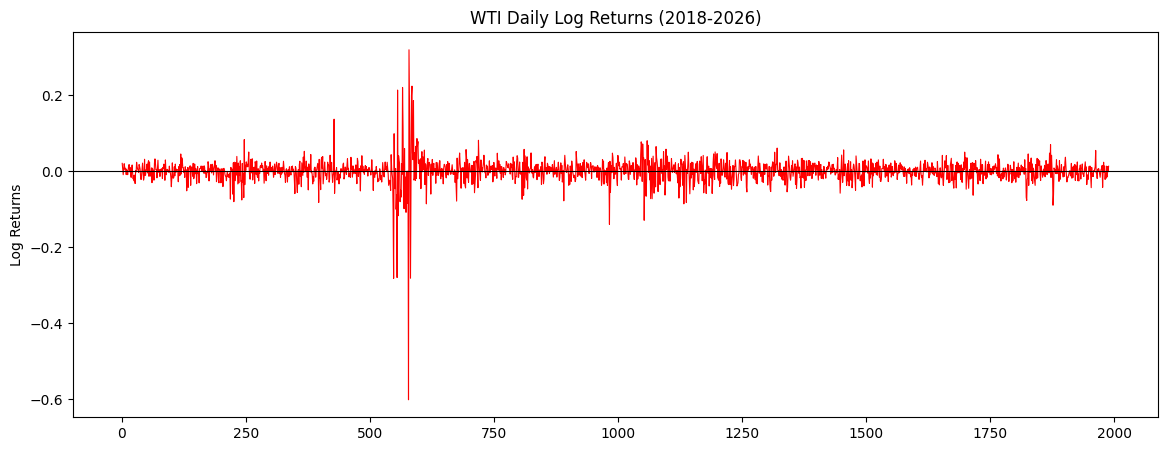

In [5]:
import matplotlib.pyplot as plt
prices = oil_df['Oil_Price']
log_returns = np.log(prices / prices.shift(1)).dropna()

plt.figure(figsize=(14, 5))
plt.plot(log_returns.index, log_returns, color='red', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('WTI Daily Log Returns (2018-2026)')
plt.ylabel('Log Returns')
plt.show()

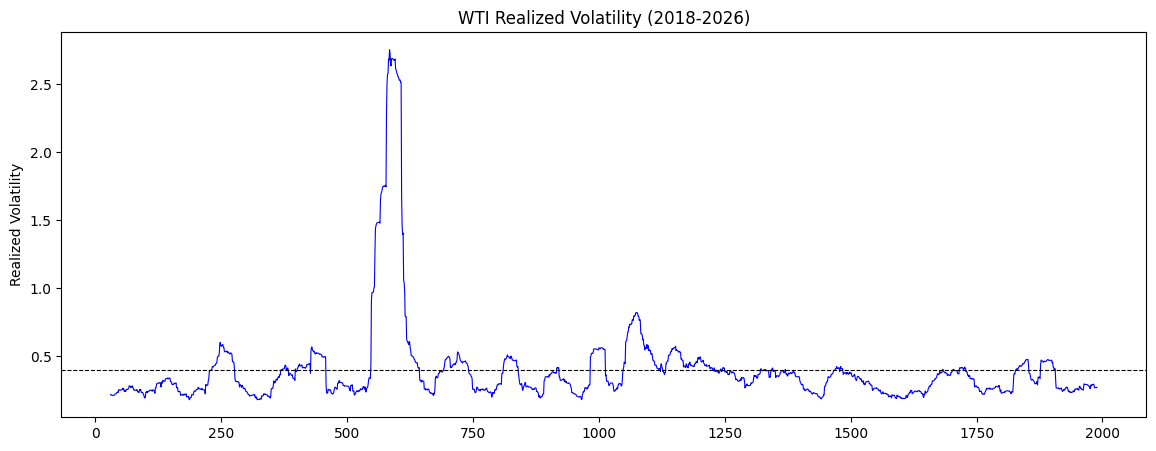

In [6]:
realized_volatility = log_returns.rolling(window=30).std() * np.sqrt(252)
realized_mean_vol = realized_volatility.mean()
plt.figure(figsize=(14, 5))
plt.plot(realized_volatility.index, realized_volatility, color='blue', linewidth=0.8)
plt.axhline(realized_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('WTI Realized Volatility (2018-2026)')
plt.ylabel('Realized Volatility')
plt.show()

In [7]:
from arch import arch_model
log_returns = log_returns.squeeze()
model = arch_model(log_returns, mean='Constant', vol='Garch', p=1, q=1)
fitted_model = model.fit(disp="off")

garch_volatility = fitted_model.conditional_volatility * np.sqrt(252)
garch_mean_vol = garch_volatility.mean()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001054. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


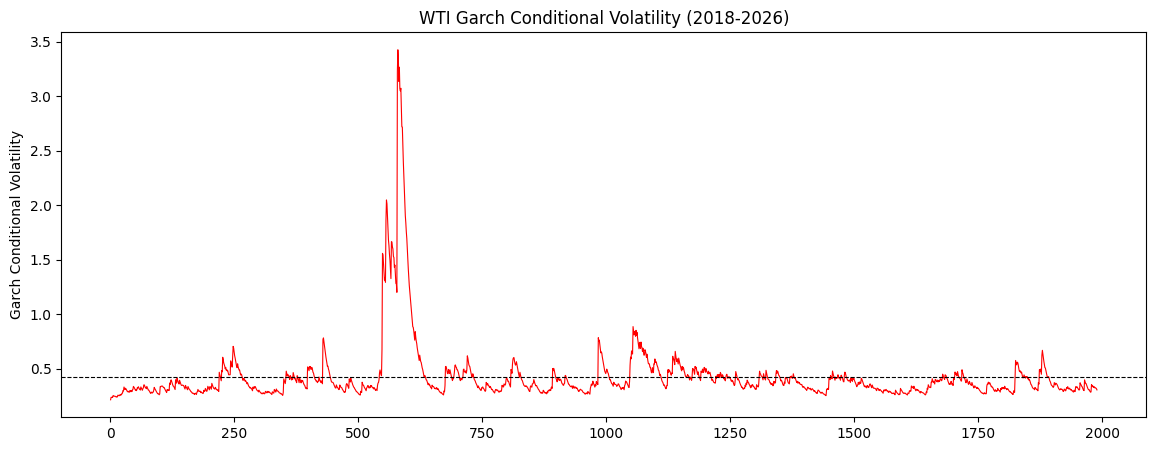

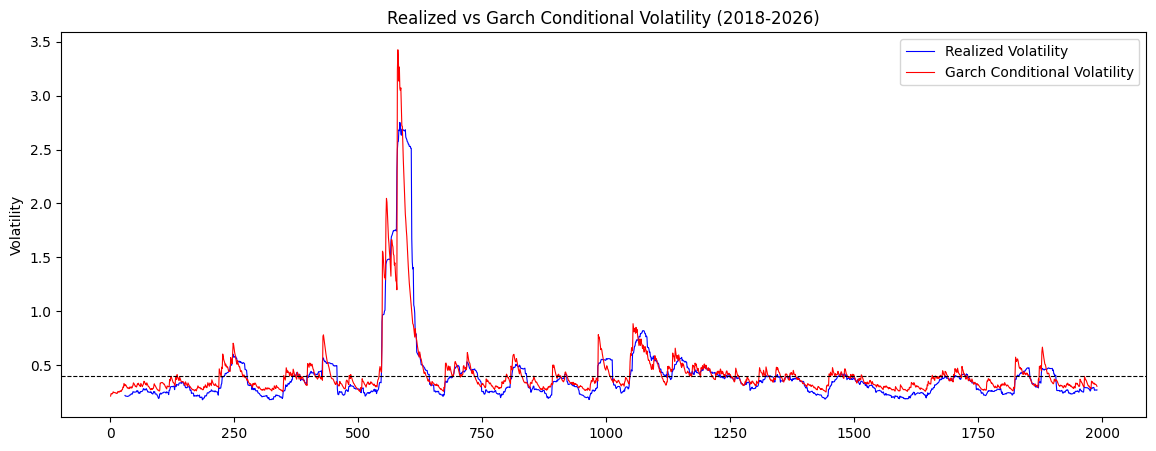

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(garch_volatility.index, garch_volatility, color='red', linewidth=0.8)
plt.axhline(garch_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('WTI Garch Conditional Volatility (2018-2026)')
plt.ylabel('Garch Conditional Volatility')
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(realized_volatility.index, realized_volatility, color='blue', linewidth=0.8)
plt.plot(garch_volatility.index, garch_volatility, color='red', linewidth=0.8)
plt.axhline(realized_mean_vol, color='black', linewidth=0.8, linestyle='--')
plt.title('Realized vs Garch Conditional Volatility (2018-2026)')
plt.ylabel('Volatility')
plt.legend(['Realized Volatility', 'Garch Conditional Volatility'])
plt.show()

